# Tutorial for R Users

In this tutorial, we will go through CausalBGM workflow with the R package **bayesgm**.

First of all, you need to install , please refer to the [install page](https://bayesgm.readthedocs.io/en/latest/getting-started/installation.html) to make sure **bayesgm** R package is installed.


<div class="alert alert-info">
<b>Notes</b>

- *bayesgm* R package was developed based on *[reticulate](https://rstudio.github.io/reticulate/)* package, which enables building R APIs based on Python APIs. Make sure the dependency R packages are installed.
- The R APIs are consistent with Python APIs, detailed usage of CausalBGM APIs can be found at **[online document](https://bayesgm.readthedocs.io/en/latest/api/models.html#causalbgm-family)**.

</div>

In [1]:
library(bayesgm)

## Dependencies

<div class="alert alert-warning">
<b>Reminder</b>

- Install the following dependent R packages for running the whole workflow.

</div>

In [2]:
#install.packages(c("reticulate", "lattice", "Matrix", "R6","png"))

<div class="alert alert-info">
<b>Notes</b>

The function **configure_bayesgm()** specifies:

* **python**: the path to the Python executable used by *reticulate*
* **pythonpath**: the directory containing the *bayesgm* Python source code
  
Make sure to replace with your **own paths** here. After configuration, you can verify that the Python backend is available by running:
**stopifnot(bayesgm_available(configure = FALSE))**

If the configuration is correct, this command will run silently; otherwise it will raise an error indicating that the Python environment or package cannot be located.

You may also run **reticulate::py_config()** to check which Python environment is currently being used by R.

</div>

In [3]:
configure_bayesgm(
  python = "~/.conda/envs/py3.9/bin/python",
  pythonpath = "/home/ql339/project_pi_ql339/ql339/bayesgm/src"
)
stopifnot(bayesgm_available(configure = FALSE))

## Binary treatment 

We first give a step-by-step tutorial for implementing CausalBGM under binary treatment settings.

### Data generation

Let's load a ACIC2018 simulation dataset (ufid='629e3d2c63914e45b227cc913c09cebe') with binary treatment.

The data contain treatment (*X*), potential outcome (*Y*), and covariates (*V*).

In [4]:
data("acic_2018_example", package = "bayesgm")

ufid <- acic_2018_example$ufid
x <- acic_2018_example$x
y <- acic_2018_example$y
v <- acic_2018_example$v
ite_true <- acic_2018_example$ite_true
ate_true <- acic_2018_example$ate_true

Let's take a look at the simulation data.

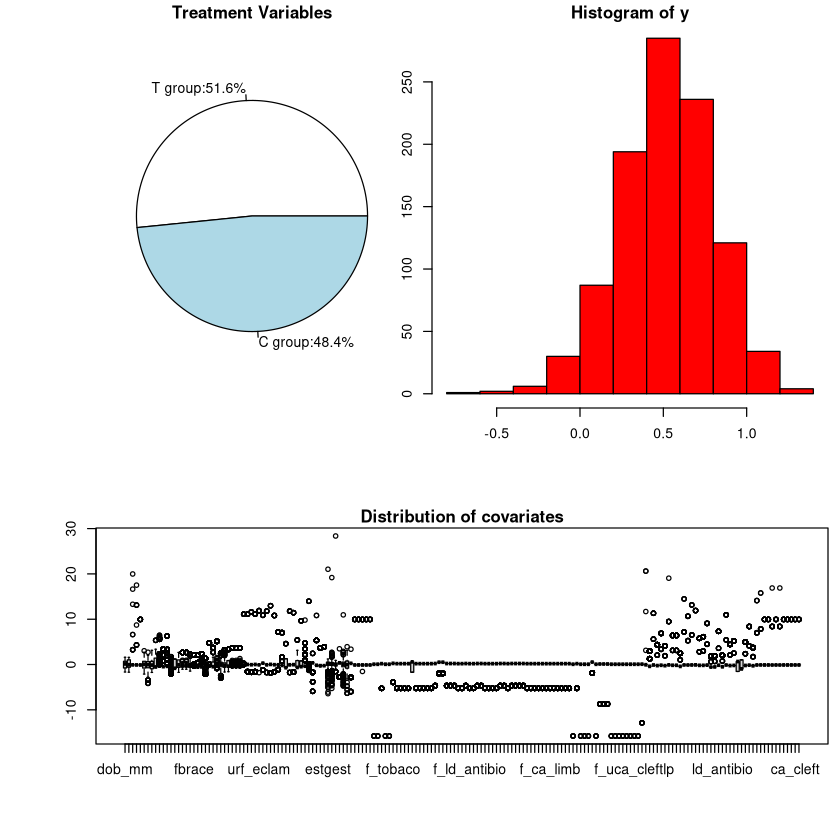

In [5]:
par(cex=0.7, mai=c(0.1,0.1,0.2,0.1))
par(fig=c(0.1,0.5,0.5,1.0))
slices <- c(sum(x==1), sum(x==0))
lbls <- c(paste("T group:",round(sum(x==1)*100/length(x), 2), "%", sep=""), paste("C group:",round(sum(x==0)*100/length(x), 2), "%", sep=""))
pie(slices, labels = lbls, main="Treatment Variables")
par(fig=c(0.5,1,0.5,1), new=TRUE)
hist(y, breaks=12, col="red",xlab="y values")
par(fig=c(0.1,1.0,0.1,0.4), new=TRUE)
boxplot(v, main="Distribution of covariates", xlab="Covariate index", ylab="Values")

### Instantiate a CausalBGM model

Before creating a CausalBGM model, parameters are needed for configing a CausalBGM model, which are described as follows.

#### General Parameters
| Config Parameter        | Description |
|-------------------------|-------------|
| `dataset`               | Dataset name to indicate the input data. *Default: 'Sim_Hirano_Imbens'.* |
| `output_dir`            | Output directory to save the results during the model training. *Default: '.'.* |
| `save_res`              | Whether to save intermediate results. *Default: TRUE.* |
| `save_model`            | Whether to save the model after training. *Default: FALSE.* |
| `binary_treatment`      | Whether to use binary treatment settings. *Default: FALSE.* |
| `use_bnn`               | Whether to use Bayesian neural networks. *Default: TRUE.* |

#### Parameters for Iterative Updating Algorithm
| Config Parameter        | Description |
|-------------------------|-------------|
| `z_dims`                | Latent dimensions of `Z`. *Default: c(3L, 6L, 3L, 6L).* |
| `v_dim`                 | Dimension of covariates. *Default: 200.* |
| `lr_theta`              | Learning rate for updating model parameters. *Default: 0.0001.* |
| `lr_z`                  | Learning rate for updating latent variables. *Default: 0.0001.* |
| `g_units`               | Number of units for covariates generative model. *Default: c(64L, 64L, 64L, 64L, 64L).* |
| `f_units`               | Number of units for outcome generative model. *Default: c(64L, 32L, 8L).* |
| `h_units`               | Number of units for treatment generative model. *Default: c(64L, 32L, 8L).* |

#### Parameters for EGM Initialization
| Config Parameter        | Description |
|-------------------------|-------------|
| `kl_weight`             | Coefficient for KL divergence term in BNNs. *Default: 0.0001.* |
| `lr`                    | Learning rate for EGM initialization. *Default: 0.0002.* |
| `g_d_freq`              | Frequency for updating discriminators and generators. *Default: 5.* |
| `use_z_rec`             | Whether to use reconstruction for latent features. *Default: True.* |
| `e_units`               | Number of units for the encoder network. *Default: c(64L, 64L, 64L, 64L, 64L).* |
| `dz_units`              | Number of units for the discriminator network in latent space. *Default: c(64L, 32L, 8L).* |

In [6]:
params <- list(
  dataset = "Semi_acic",
  output_dir = tempdir(),
  save_res = FALSE,
  save_model = FALSE,
  binary_treatment = TRUE,
  use_bnn = TRUE,
  z_dims = c(3L, 6L, 3L, 6L),
  v_dim = 177L,
  lr_theta = 0.0001,
  lr_z = 0.0001,
  g_units = c(64L, 64L, 64L, 64L, 64L),
  f_units = c(64L, 32L, 8L),
  h_units = c(64L, 32L, 8L),
  kl_weight = 0.0001,
  lr = 0.0002,
  g_d_freq = 5L,
  use_z_rec = TRUE,
  e_units = c(64L, 64L, 64L, 64L, 64L),
  dz_units = c(64L, 32L, 8L)
)

model <- CausalBGM(params = params, random_seed = NULL)

### Model training

Train CausalBGM with an optional EGM warm-start. 

| Config Parameter        | Description |
|-------------------------|-------------|
| `x`                     | Treatment, *Required.* |
| `y`                     | Outcome, *Required.* |
| `v`                     | Covariates, *Required.* |
| `batch_size`            | Batch size for training. *Default: 32.* |
| `epochs`                | Number of epochs for training. *Default: 100.* |
| `epochs_per_eval`       | Frequency of evaluations during training (e.g., every 5 epochs). *Default: 5.* |
| `use_egm_init`          | Whether to run EGM initialization before iterative training. *Default: True.* |
| `epochs_per_eval`       | Frequency of evaluations during training (e.g., every 5 epochs). *Default: 5.* |
| `egm_n_iter`            | Number of EGM initialization iterations. *Default: 30000.* |
| `egm_batches_per_eval`  | Evaluate EGM initialization every this many iterations. *Default: 500.* |
| `verbose`               | Controls verbosity level, showing progress and evaluation metrics. *Default: 1.* |


<div class="alert alert-info">
<b>Notes</b>
    
The training procedure consists of two phases:
- **EGM initialization** (optional) — warm-start to obtain a good starting point for the latent variables and model parameters. This phase is optional and can be skipped by setting *use_egm_init* to False.
- **Stochastic iterative updating** — alternates between updating the generator network parameters 
 and the per-sample latent variables via stochastic gradient optimization.

</div>

In [7]:
model <- model$fit(
    x = x,
    y = y,
    v = v,
    epochs = 100L,
    epochs_per_eval = 10L,
    batch_size = 32L,
    use_egm_init = TRUE,
    egm_n_iter = 30000L,
    egm_batches_per_eval = 500L,
    verbose = 1L
)

### Model Prediction

Estimate causal effects with posterior intervals from latent MCMC samples.

| Config Parameter        | Description |
|-------------------------|-------------|
| `x`                     | Treatment, *Required.* |
| `y`                     | Outcome, *Required.* |
| `v`                     | Covariates, *Required.* |
| `alpha`                | Significance level for the posterior interval. *Default: 0.01.* |
| `n_mcmc`               | Number of posterior MCMC samples to draw. *Default: 3000.* |
| `burn_in`              | Number of burn-in MCMC samples before drawing. *Default: 5000.* |
| `q_sd`                 | Standard deviation for the proposal distribution used in Metropolis-Hastings (MH) sampling. *Default: 1.0.* |
| `sample_y`             | Whether to consider the variance function in the outcome generative model. *Default: True.* |
| `bs`                   | Batch size in inference stage, denoting number of test subjects processed per batch prediction. *Default: 10000.* |

| Return     | Type          | Description                                                                                             | Shape       |
|------------|---------------|---------------------------------------------------------------------------------------------------------|-------------|
| `res$effect`     | `numeric vector`  | Point estimates of the Individual Treatment Effect (ITE).                                                  | `(length(x))` |
| `res$interval`  | `numeric matrix`  | Posterior intervals for the ITEs, representing `[lower bound, upper bound]` | `(length(x), 2)` 

In [8]:
res <- model$predict(
    x = x,
    y = y,
    v = v,
    alpha = 0.01,
    n_mcmc = 3000L,
    burn_in = 5000L,
    q_sd = 1.0
)
pred_ite <- as.numeric(res$effect)
pred_interval <- as.matrix(res$interval)

### Model Evaluation

For this ACIC example, the package dataset includes the ground-truth
counterfactual outcomes, so the true individual treatment effects and average
treatment effect are available directly.

In [9]:
pred_ate <- mean(pred_ite)
delta_ate <- abs(pred_ate - ate_true)
delta_pehe <- mean((pred_ite - ite_true)^2)


cat(sprintf(
  "Delta ATE (Absolute Error in Average Treatment Effect): %.4f\n",
  delta_ate
))
cat(sprintf(
  "Delta PEHE (Precision in Estimation of Heterogeneous Effect): %.4f\n",
  delta_pehe
))

Delta ATE (Absolute Error in Average Treatment Effect): 0.0037
Delta PEHE (Precision in Estimation of Heterogeneous Effect): 0.0002


## Continuous treatment

We first give a step-by-step tutorial for implementing CausalBGM under continuous treatment settings. We use the Hirano and Imbens simulation dataset for an example.

In [10]:
sim_data <- load_sim_hirano_imbens(N = 20000L, v_dim = 200L, seed = 0L)

x <- sim_data$x
y <- sim_data$y
v <- sim_data$v
grid_val <- seq(0, 3, length.out = 20)
true_effect <- grid_val + 2 * (1 + grid_val)^(-3)

Let's take a look at the simulation data.

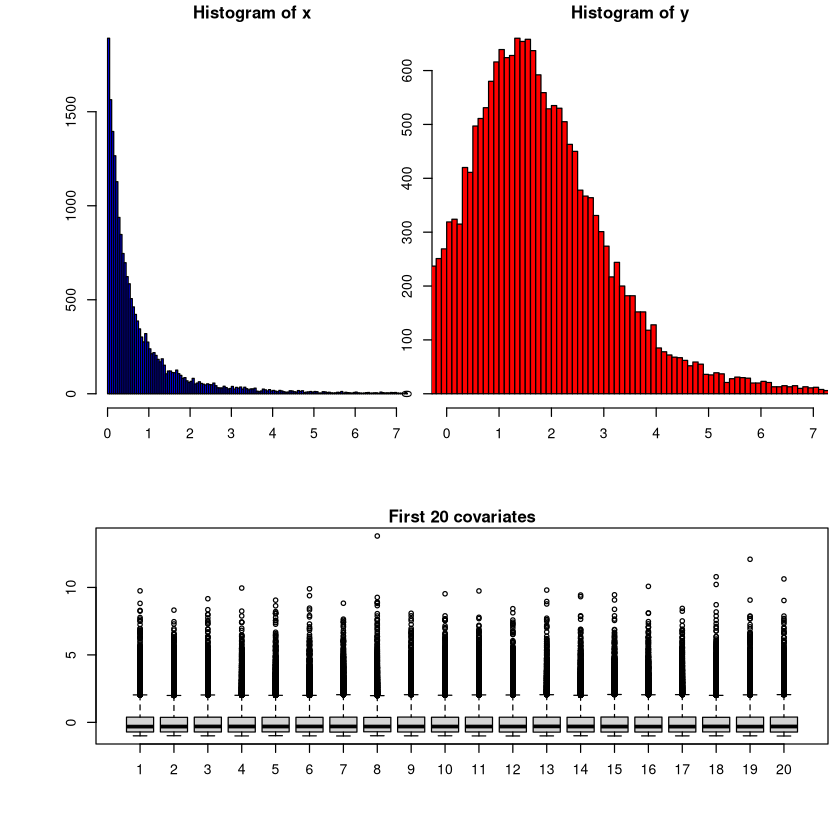

In [11]:
par(cex=0.7, mai=c(0.1,0.1,0.2,0.1))
par(fig=c(0.1,0.5,0.5,1.0))
hist(x, breaks="FD", xlim=c(0,7), col="blue",xlab="x values")
par(fig=c(0.5,1,0.5,1), new=TRUE)
hist(y, breaks="FD", xlim=c(0,7), col="red",xlab="y values")
par(fig=c(0.1,1.0,0.1,0.4), new=TRUE)
boxplot(v[,1:20],main="First 20 covariates", xlab="Covariate index", ylab="v values")


### Instantiate a CausalBGM model

In [12]:
params <- list(
  dataset = "Sim_Hirano_Imbens",
  output_dir = tempdir(),
  save_res = FALSE,
  save_model = FALSE,
  binary_treatment = FALSE,
  use_bnn = TRUE,
  z_dims = c(1L, 1L, 1L, 7L),
  v_dim = 20L,
  lr_theta = 0.0001,
  lr_z = 0.0001,
  g_units = c(64L, 64L, 64L, 64L, 64L),
  f_units = c(64L, 32L, 8L),
  h_units = c(64L, 32L, 8L),
  kl_weight = 0.0001,
  lr = 0.0002,
  g_d_freq = 5L,
  use_z_rec = TRUE,
  e_units = c(64L, 64L, 64L, 64L, 64L),
  dz_units = c(64L, 32L, 8L)
)

model <- CausalBGM(params = params, random_seed = NULL)

### Model Training

Train CausalBGM with an optional EGM warm-start. 

| Config Parameter        | Description |
|-------------------------|-------------|
| `x`                     | Treatment, *Required.* |
| `y`                     | Outcome, *Required.* |
| `v`                     | Covariates, *Required.* |
| `batch_size`            | Batch size for training. *Default: 32.* |
| `epochs`                | Number of epochs for training. *Default: 100.* |
| `epochs_per_eval`       | Frequency of evaluations during training (e.g., every 5 epochs). *Default: 5.* |
| `use_egm_init`          | Whether to run EGM initialization before iterative training. *Default: True.* |
| `epochs_per_eval`       | Frequency of evaluations during training (e.g., every 5 epochs). *Default: 5.* |
| `egm_n_iter`            | Number of EGM initialization iterations. *Default: 30000.* |
| `egm_batches_per_eval`  | Evaluate EGM initialization every this many iterations. *Default: 500.* |
| `verbose`               | Controls verbosity level, showing progress and evaluation metrics. *Default: 1.* |

In [13]:
model <- model$fit(
    x = x,
    y = y,
    v = v,
    epochs = 100L,
    epochs_per_eval = 10L,
    batch_size = 32L,
    use_egm_init = TRUE,
    egm_n_iter = 30000L,
    egm_batches_per_eval = 500L,
    verbose = 1L
)

### Model Prediction

Estimate causal effects with posterior intervals from latent MCMC samples.

| Config Parameter        | Description |
|-------------------------|-------------|
| `x`                     | Treatment, *Required.* |
| `y`                     | Outcome, *Required.* |
| `v`                     | Covariates, *Required.* |
| `alpha`                | Significance level for the posterior interval. *Default: 0.01.* |
| `n_mcmc`               | Number of posterior MCMC samples to draw. *Default: 3000.* |
| `burn_in`              | Number of burn-in MCMC samples before drawing. *Default: 5000.* |
| `x_values`             | Treatment value(s) for dose-response function to be predicted. *Examples: 1.0 or c(1.0, 2.0)* |
| `q_sd`                 | Standard deviation for the proposal distribution used in Metropolis-Hastings (MH) sampling. *Default: 1.0.* |
| `sample_y`             | Whether to consider the variance function in the outcome generative model. *Default: True.* |
| `bs`                   | Batch size in inference stage, denoting number of test subjects processed per batch prediction. *Default: 10000.* |


| Return     | Type          | Description                                                                                             | Shape       |
|------------|---------------|---------------------------------------------------------------------------------------------------------|-------------|
| `res$effect`     | `numeric vector`  | Point estimates of the Average Dose-Response Function.                                                  | `(length(x_values))` |
| `res$interval`  | `numeric matrix`  | Posterior intervals for the ADRF, representing `[lower bound, upper bound]` | `(length(x_values), 2)` 

In [14]:
res <- model$predict(
    x = x,
    y = y,
    v = v,
    alpha = 0.05,
    x_values = grid_val,
    n_mcmc = 3000L,
    burn_in = 5000L,
    q_sd = 1.0
)

pred_effect <- as.numeric(res$effect)
pred_interval <- as.matrix(res$interval)
pred_lower <- pred_interval[, 1]
pred_upper <- pred_interval[, 2]

### Model Evaluation

In [15]:
rmse <- sqrt(mean((true_effect - pred_effect)^2))
mape <- mean(abs((true_effect - pred_effect) / true_effect))

cat(sprintf(
  "RMSE (Root Mean Squared Error): %.4f\n",
  rmse
))
cat(sprintf(
  "MAPE (Mean Absolute Percentage Error): %.4f\n",
  mape
))

RMSE (Root Mean Squared Error): 0.0289
MAPE (Mean Absolute Percentage Error): 0.0110


### Plot of the average dose-response function (ADRF)

We now compare plot of the true ADRF and the ADRF estimated by our model.

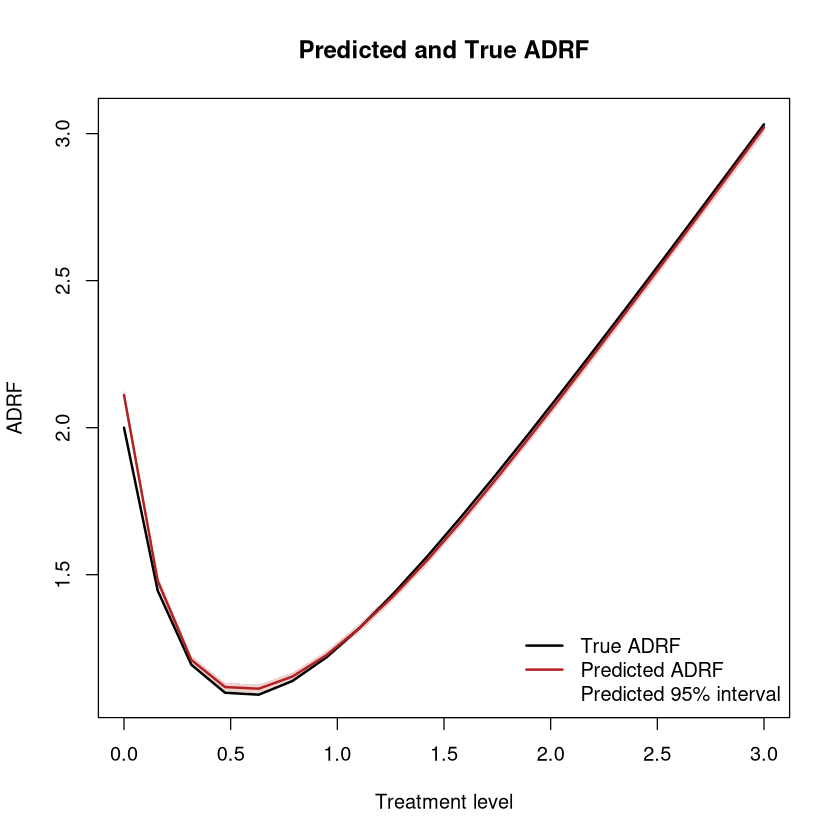

In [16]:
plot(
  grid_val,
  true_effect,
  type = "n",
  ylim = range(c(true_effect, pred_lower, pred_upper), finite = TRUE),
  xlab = "Treatment level",
  ylab = "ADRF",
  main = "Predicted and True ADRF"
)
polygon(
  x = c(grid_val, rev(grid_val)),
  y = c(pred_lower, rev(pred_upper)),
  border = NA,
  col = grDevices::adjustcolor("firebrick", alpha.f = 0.2)
)
lines(grid_val, true_effect, col = "black", lwd = 2)
lines(grid_val, pred_effect, col = "firebrick", lwd = 2)
legend(
  "bottomright",
  legend = c("True ADRF", "Predicted ADRF", "Predicted 95% interval"),
  col = c("black", "firebrick", NA),
  lty = c(1, 1, NA),
  lwd = c(2, 2, NA),
  pch = c(NA, NA, 15),
  pt.cex = c(NA, NA, 2),
  pt.bg = c(NA, NA, grDevices::adjustcolor("firebrick", alpha.f = 0.2)),
  bty = "n"
)

In [17]:
sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Red Hat Enterprise Linux 8.10 (Ootpa)

Matrix products: default
BLAS/LAPACK: FlexiBLAS OPENBLAS;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] bayesgm_0.1.0

loaded via a namespace (and not attached):
 [1] crayon_1.5.3      vctrs_0.6.5       cli_3.6.3         rlang_1.1.4      
 [5] png_0.1-8         jsonlite_1.8.9    glue_1.8.0        htmltools_0.5.8.1
 [9] IRdisplay_1.1     IRkernel_1.3.2    fa